# Phase 1: How Decision Trees Handle Regression

When you build a **classification tree**, the goal is to group data points of the same category together using **Entropy** or **Gini Impurity**. But what if you are trying to predict the price of a house? You don't have categories. Every house has a unique floating-point number. You can't calculate the "Entropy" of continuous numbers.

### 1. The New Math of Chaos: Mean Squared Error (MSE)

Instead of measuring categorical chaos, a **Regression Tree** measures **Variance** (how widely spread out the numbers are). It uses **Mean Squared Error (MSE)**.

When the tree looks at a group of houses in a bucket, it calculates the **average price** of all the houses. Then, it measures how far off every individual house is from that average:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

*   $y_i$ is the actual price of a specific house.
*   $\bar{y}$ is the average price of all houses in that bucket.
*   $n$ is the number of houses in the bucket.

### 2. The Splitting Logic (Variance Reduction)

Just like **Information Gain** in classification, the tree tests thousands of splits (e.g., "Is Square Footage > 2000?").

It calculates the MSE of the parent bucket, and then calculates the MSE of the two new child buckets. It chooses the split that causes the **largest drop in MSE**. *Translation: It wants to create buckets where all the houses inside have nearly identical prices.*

### 3. The Final Prediction (The Averages)

In classification, a leaf node takes a "majority vote" (e.g., 90% Spam, so predict Spam).

In regression, a leaf node simply takes the **average** of all the numbers inside it.

If a leaf bucket ends up containing three houses priced at $100k, $110k, and $120k, the final prediction for any new data point that lands in that bucket is exactly **$110k**.

Because of this averaging mechanism, a Regression Tree does not draw smooth curves. It draws **staircases (step functions)**.

# Phase 2: Coding and Visualizing the Regression Tree

Let's see this "staircase" geometry in action. We are going to generate a non-linear sine wave dataset with some random noise scattered around it.

We will train two models:

1. The Overfitted Monster (Max Depth = None): It will try to hit every single noisy dot.

2. The Pruned Professional (Max Depth = 3): It will capture the general wave pattern using broad, generalized steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

Text(0.5, 1.0, 'Before Adding Noise to the data')

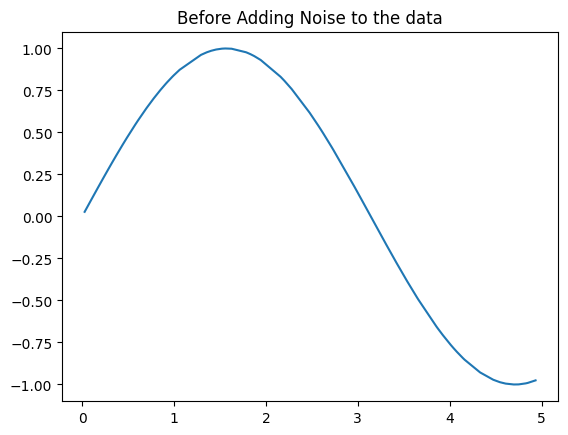

In [6]:
# Generating non-linear regression data
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0) # 80 random numbers between 0-5
y = np.sin(X).ravel()  # calculating the sine wave

plt.plot(X, y)
plt.title("Before Adding Noise to the data")

Text(0.5, 1.0, 'After Adding Noise to the data')

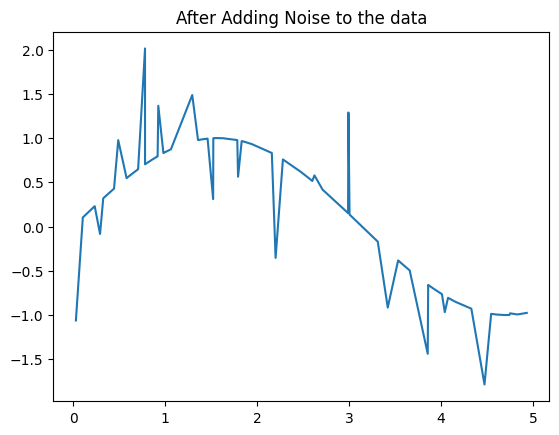

In [7]:
# injecting realistic noise
y[::5] += 3 * (0.5 - rng.rand(16))

plt.plot(X, y)
plt.title("After Adding Noise to the data")

In [8]:
# Trainign the regression trees
tree_unrestricted = DecisionTreeRegressor(random_state=42)
tree_unrestricted.fit(X, y)

tree_pruned = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_pruned.fit(X, y)

# predict accross the entire axis
# Create a densely packed X-axis to see the exact shape of the predictions
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

y_pred_unrestricted = tree_unrestricted.predict(X_test)
y_pred_pruned = tree_pruned.predict(X_test)

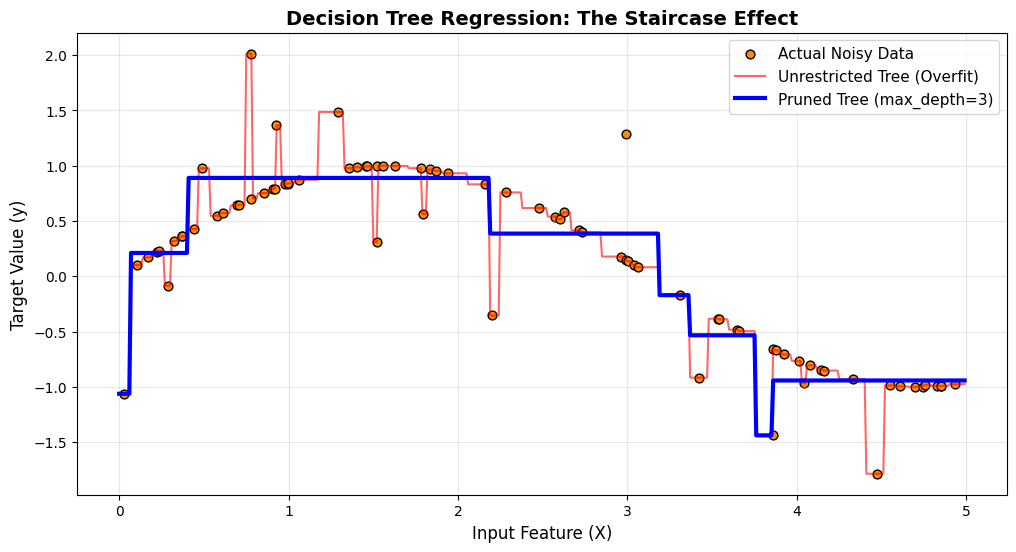

In [9]:
# Finally: Visualizing the staircase geometry
plt.figure(figsize=(12, 6))

# Plot the raw, noisy data points
plt.scatter(X, y, s=40, edgecolor="black", c="darkorange", label="Actual Noisy Data")

# Plot the Unrestricted Model
plt.plot(X_test, y_pred_unrestricted, color="red", label="Unrestricted Tree (Overfit)", linewidth=1.5, alpha=0.6)

# Plot the Pruned Model
plt.plot(X_test, y_pred_pruned, color="blue", label="Pruned Tree (max_depth=3)", linewidth=3)

plt.title("Decision Tree Regression: The Staircase Effect", fontsize=14, fontweight='bold')
plt.xlabel("Input Feature (X)", fontsize=12)
plt.ylabel("Target Value (y)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# results:

We can clearly see that unrestricted data is trying to overfit and it will eventually fail on the test data, but that pruned data will not fail on training data and will perform better on test data.